In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import gseapy as gp
import os
import pickle

import subcluster_funcs as funcs
sc._settings.settings._vector_friendly=True

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [2]:
post_subclustering_dir = "../post_subcluster_annotation/"
os.makedirs(post_subclustering_dir, exist_ok=True)

In [3]:
cell_type = "vSMC"

In [4]:
adata = sc.read_h5ad("../post_subclustering/" + cell_type  + ".h5ad")

<Axes: xlabel='leiden', ylabel='sil_score'>

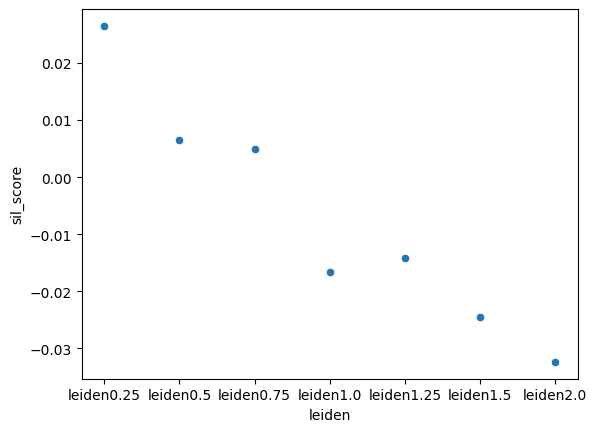

In [5]:
funcs.silhouette(adata, cell_type = cell_type)

### Leiden 0.25 subclustering

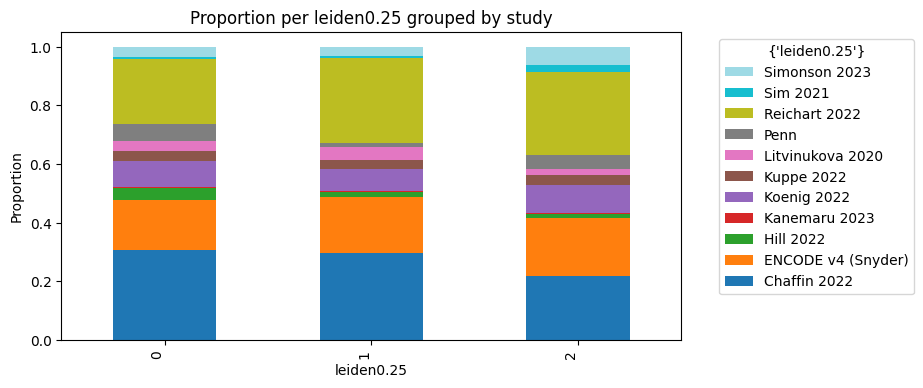

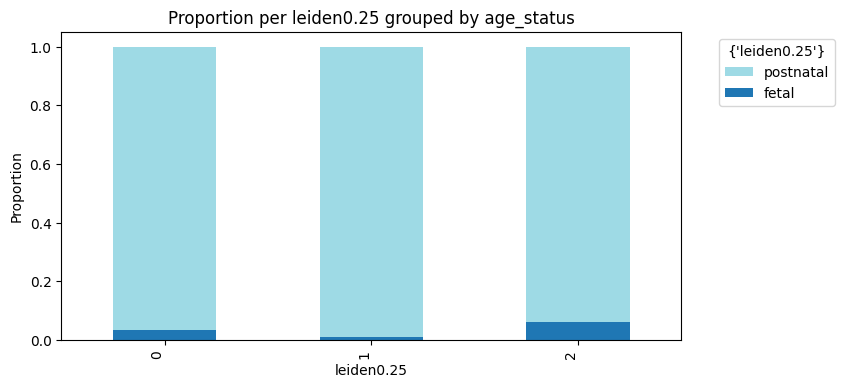

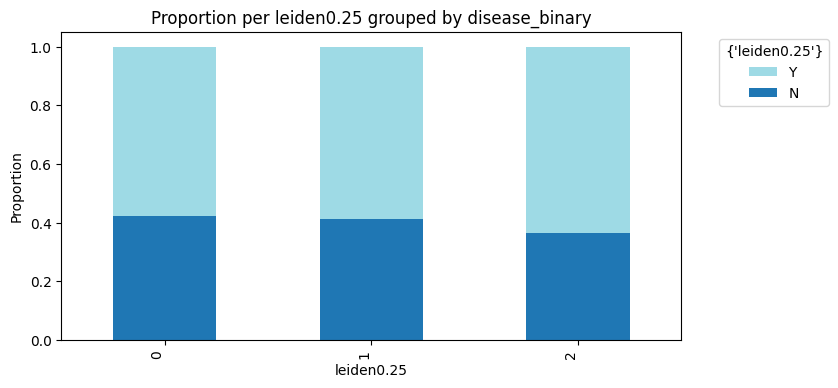

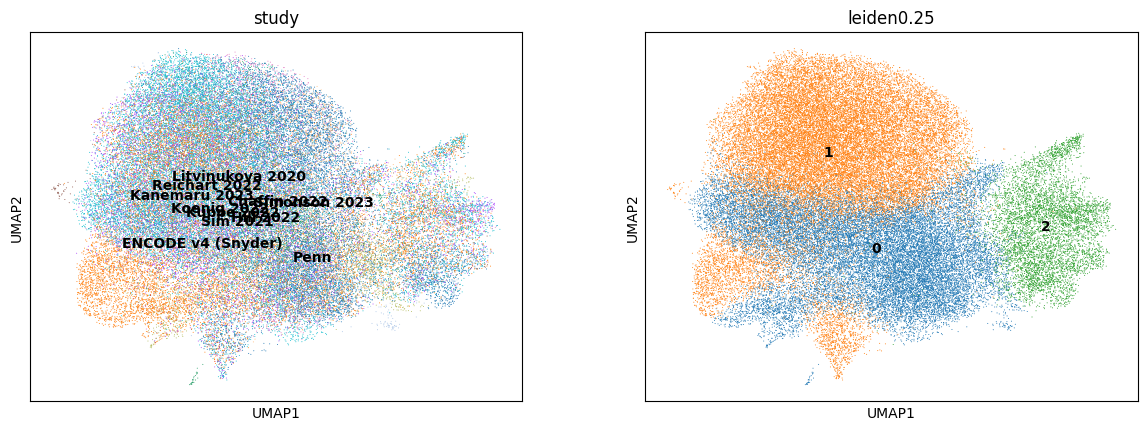

/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:458: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:459: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:458: RuntimeWarning: invalid value encountered in divide
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:458: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:459: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean

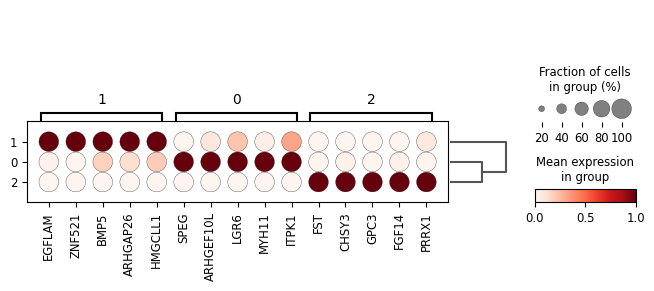

Counter({'1': 29868, '0': 23247, '2': 6242})


['leiden0.25',
 AnnData object with n_obs × n_vars = 59357 × 16115
     obs: 'age', 'donor_id', 'sex', 'region', 'cell_type', 'disease', 'consistent_cell_type', 'study', 'technology', 'cell_or_nuclei', 'barcode', 'sample_id', 'age_status', 'tech_plus_study', 'disease_binary', 'decade', 'age_group', '_scvi_batch', '_scvi_labels', 'leiden_scVI', 'scvi_cell_type', 'redo_leiden_0.5', 'UMAP1', 'UMAP2', 'v2_scvi_cell_type', 'final_cell_type', 'leiden0.1', 'leiden0.25', 'leiden0.5', 'leiden0.75', 'leiden1.0', 'leiden1.25', 'leiden1.5', 'leiden1.75', 'leiden2.0'
     var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
     uns: '_scvi_manager_uuid', '_scvi_uuid', 'hvg', 'leiden0.1', 'leiden0.25', 'leiden0.5', 'leiden0.75', 'leiden1.0', 'leiden1.25', 'leiden1.5', 'leiden1.75', 'leiden2.0', 'neighbors', 'pca', 'rank_genes_groupsleiden0.25', 'rank_genes_groupsleiden0.5', 'rank_genes_groupsleiden0.75', 'rank_genes_groupsleiden1.0', 'rank_genes_groupsleiden1.25', 

In [6]:
funcs.specify_leiden_subclustering(adata=adata, leiden="leiden0.25")

- Cluster 0 is the contractile vSMC (MYH11/SPEG/ALPK3)
- Cluster 1 are pericyte-like, with expression of genes such as EGFLAM/ZEB1/NDRG2
- Cluster 2 have many fibroblast markers, suggesting they are fibroblast-like/fibromyocytes (DUM/COL1A1/FN1) 

In [38]:
sc.get.rank_genes_groups_df(adata, group="2").head(50)['names']

0           FST
1         CHSY3
2          GPC3
3         FGF14
4         PRRX1
5          HTR7
6         RFTN1
7          HUNK
8         SULF1
9         NCOA7
10         EXT1
11         SDC2
12        LIMA1
13        DAAM1
14        ASAP1
15      CABLES1
16     TMEM200A
17        ITSN1
18          CFH
19     ARHGAP15
20      ADAMTS2
21        SVEP1
22        ITGB8
23        SAMD3
24        BICD1
25        SASH1
26     ARHGAP28
27         PODN
28       PAPPA2
29       COL6A3
30        GLIS3
31       MAMLD1
32       PIEZO2
33         TLN2
34         CD44
35        PELI2
36         ART4
37     GRM5-AS1
38    LINC00578
39         ANK3
40        TRAM2
41     NAALADL2
42         MID1
43         PID1
44         ROR2
45        KCNT2
46        VGLL3
47        MMP19
48        ITGA1
49       ELMOD1
Name: names, dtype: object

In [39]:
adata.obs['subcluster'] = adata.obs['leiden0.25'].map(
    {"0": "Contractile",
     "1": "Pericyte-like",
     "2": "Synthetic"
    }
)

In [42]:
subcluster_order = [
    "Contractile",
    "Pericyte-like",
    "Synthetic"
]

adata.obs['subcluster'] = pd.Categorical(
    adata.obs['subcluster'], categories=subcluster_order, ordered=True
)

subcluster_colors = {
    "Contractile": "cyan",
    "Pericyte-like": "orange",
    "Synthetic": "red"
}

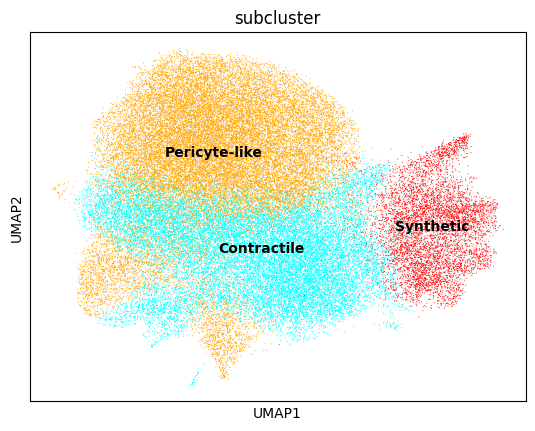

In [43]:
with plt.rc_context(): 
    sc.pl.umap(adata, color = ['subcluster'], legend_loc = "on data", palette = subcluster_colors, show=False)
    plt.savefig("vSMC_subclustered.pdf", bbox_inches="tight")

- Cluster 0 is the contractile vSMC (MYH11/SPEG/ALPK3)
- Cluster 1 are support vSMC (COX4I2/THSD7A/PPARGC1B)
- Cluster 2 are activated vSMC (ADAMTS2/SVEP1/EXT1) 

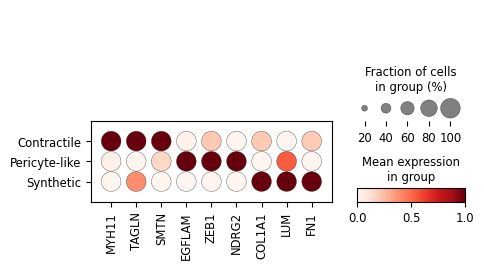

In [44]:
with plt.rc_context(): 
    sc.pl.dotplot(adata, var_names = ["MYH11", "TAGLN", "SMTN",
                                      "EGFLAM", "ZEB1", "NDRG2",
                                  "COL1A1", "LUM", "FN1"], groupby = "subcluster", 
                  standard_scale='var', show=False)
    plt.savefig("vSMC_subclustered_dotplot.pdf", bbox_inches="tight")

In [45]:
subcluster_stats = (
    adata.obs['subcluster']
    .value_counts(normalize=False)
    .rename("count")
    .reset_index()
    .rename(columns={"index": "subcluster"})
)

subcluster_stats["proportion"] = subcluster_stats["count"] / subcluster_stats["count"].sum()

print(subcluster_stats)

      subcluster  count  proportion
0  Pericyte-like  29868    0.503193
1    Contractile  23247    0.391647
2      Synthetic   6242    0.105160
